# Neural Networks: Perceptrons, Activations, and Loss Functions

## What This Notebook Is About

This notebook is my hands-on exploration of the foundational building blocks of deep
learning. Before using any high-level framework features, I want to understand what is
actually happening at the neuron level — how a single perceptron computes an output,
what activation functions do and why they matter, and how a loss function guides the
learning process.

The model I build here is a simple Multi-Layer Perceptron (MLP) trained on the Iris
dataset. The goal is not to get the best accuracy — it is to understand every step
clearly enough to explain it.

## Why the Iris Dataset

Iris is small, clean, and requires no preprocessing beyond normalisation. It has three
classes and four features, which makes it ideal for a classification network without any
data engineering distraction.

## What I Want to Understand

- What does a single perceptron actually compute?
- Why do we need activation functions — what goes wrong without them?
- How does a loss function know which direction to push the weights?
- What does backpropagation look like in a simple training loop?
- How do I build and train a network in PyTorch from scratch using nn.Module?

## Dataset

| Property | Detail |
|---|---|
| Name | Iris |
| Source | sklearn.datasets.load_iris |
| Samples | 150 |
| Features | 4 (sepal length, sepal width, petal length, petal width) |
| Classes | 3 (Setosa, Versicolor, Virginica) |
| Download required | No |

## Tech Stack

| Tool | Purpose |
|---|---|
| Python 3.13 | Language |
| PyTorch 2.11 | Model definition and training |
| scikit-learn | Dataset loading and train/test split |
| NumPy | Numerical operations |
| Matplotlib | Visualisations |

## Setup and Imports

Importing everything needed for this notebook upfront. PyTorch's `nn` module provides
the building blocks for defining the network. `sklearn` handles data loading and
splitting. `matplotlib` is used for all visualisations throughout the notebook.

I am setting a random seed for both NumPy and PyTorch so that results are reproducible
across runs.

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

plt.style.use("seaborn-v0_8-whitegrid")

print("PyTorch version:", torch.__version__)
print("NumPy version:", np.__version__)

PyTorch version: 2.11.0+cpu
NumPy version: 2.4.4


## Load and Explore the Dataset

Loading the Iris dataset directly from scikit-learn — no file download needed. Before
building anything, I want to understand the shape of the data, the class distribution,
and whether the features are on comparable scales.

The class distribution matters because an imbalanced dataset can silently bias a
classifier. Checking it early avoids surprises later.

In [4]:
iris = load_iris()

X = iris.data
y = iris.target
class_names = iris.target_names
feature_names = iris.feature_names

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("Classes:", class_names)
print("Feature names:", feature_names)
print()
print("First 5 rows:")
print(X[:5])
print()
print("Class distribution:")
for i, name in enumerate(class_names):
    print(f"  {name}: {np.sum(y == i)} samples")

Feature matrix shape: (150, 4)
Target vector shape: (150,)
Classes: ['setosa' 'versicolor' 'virginica']
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

First 5 rows:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]

Class distribution:
  setosa: 50 samples
  versicolor: 50 samples
  virginica: 50 samples


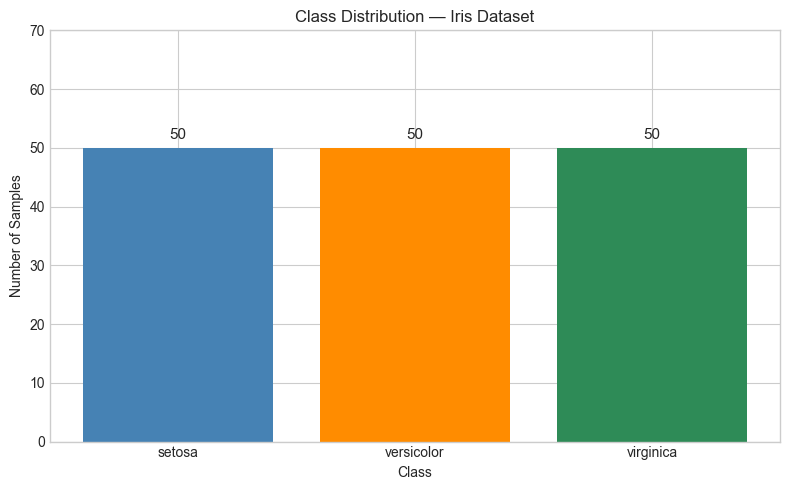

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

counts = [np.sum(y == i) for i in range(len(class_names))]
ax.bar(class_names, counts, color=["steelblue", "darkorange", "seagreen"])
ax.set_title("Class Distribution — Iris Dataset")
ax.set_xlabel("Class")
ax.set_ylabel("Number of Samples")
ax.set_ylim(0, 70)

for i, count in enumerate(counts):
    ax.text(i, count + 1, str(count), ha="center", va="bottom", fontsize=11)

plt.tight_layout()
plt.show()

### Observation

The dataset is perfectly balanced — 50 samples per class. This means accuracy is a
fair metric and there is no need for class weighting in the loss function.

The feature values are on different scales (e.g. sepal length in cm vs petal width in
cm but with a much smaller range), which means normalisation will matter before feeding
data into the network.

## What is a Perceptron?

Before using PyTorch, I want to build a single neuron by hand to understand what is
actually being computed.

A perceptron takes a vector of inputs, multiplies each by a weight, sums the results,
adds a bias, and passes the output through an activation function. In matrix form this
is simply:

    output = activation(X @ W + b)

Where:
- X is the input vector (one sample, 4 features for Iris)
- W is the weight vector (one weight per feature)
- b is a scalar bias term
- activation is a non-linear function applied to the result

At this stage the weights are random — the perceptron is not trained. The point here
is just to see the mechanics of a forward pass with no framework magic involved.

In [6]:
np.random.seed(RANDOM_SEED)

# one sample from the dataset
sample = X[0]
print("Input (one Iris sample):", sample)
print("True class:", class_names[y[0]])
print()

# random weights and bias — one weight per feature
weights = np.random.randn(4)
bias = np.random.randn()
print("Weights:", weights)
print("Bias:", bias)
print()

# linear combination
linear_output = np.dot(sample, weights) + bias
print("Linear output (X @ W + b):", linear_output)
print()

# sigmoid activation applied manually
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

activated_output = sigmoid(linear_output)
print("After sigmoid activation:", activated_output)
print()
print("This is a single number between 0 and 1.")
print("With random weights it means nothing yet — training is what gives weights meaning.")

Input (one Iris sample): [5.1 3.5 1.4 0.2]
True class: setosa

Weights: [ 0.49671415 -0.1382643   0.64768854  1.52302986]
Bias: -0.23415337472333597

Linear output (X @ W + b): 3.0265336761573787

After sigmoid activation: 0.9537585372537157

This is a single number between 0 and 1.
With random weights it means nothing yet — training is what gives weights meaning.


### Observation

The perceptron produces a single scalar output — a number between 0 and 1 after the
sigmoid. With random weights this number is meaningless, but the mechanics are clear:
it is just a weighted sum followed by a non-linear squash.

A full neural network is many of these neurons stacked in layers. The first layer
transforms the raw input, each subsequent layer transforms the previous layer's output,
and the final layer produces a prediction.

The key question this raises for me: if every neuron is just a linear combination,
why does stacking them help? The answer is the activation function — without it,
any number of stacked linear layers collapses back into a single linear transformation.
This is why activations are not optional.

## Activation Functions

Activation functions introduce non-linearity into the network. Without them, stacking
multiple layers is mathematically equivalent to a single linear transformation — no
matter how deep the network is, it could only learn linear decision boundaries.

I want to implement and visualise the four most common activation functions to
understand their shapes, ranges, and where each is typically used:

- **Sigmoid** — squashes output to (0, 1). Used in binary classification output layers.
  Problem: gradients vanish for very large or very small inputs.
- **Tanh** — squashes output to (-1, 1). Zero-centred, which helps gradient flow
  compared to sigmoid. Still suffers from vanishing gradients at extremes.
- **ReLU** — outputs 0 for negative inputs, identity for positive. Simple and effective.
  The default choice for hidden layers. Problem: neurons can "die" if they get stuck
  in the negative region permanently.
- **Softmax** — converts a vector of raw scores into a probability distribution that
  sums to 1. Used in the output layer for multi-class classification.

The goal here is to see these functions visually and understand what each one does to
an input value before any training happens.

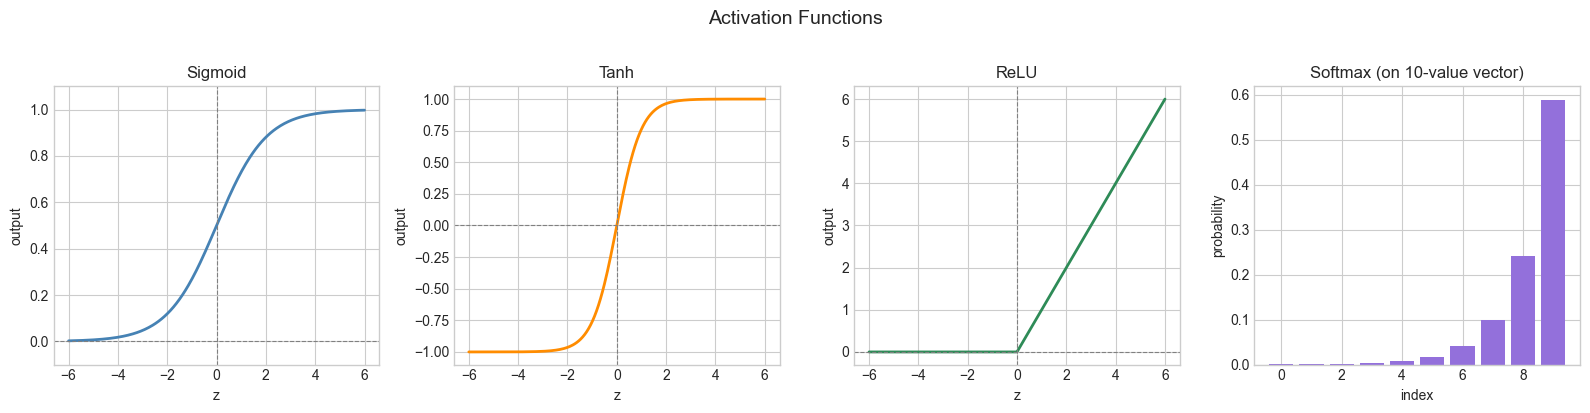

Softmax output sums to: 1.0


In [7]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def tanh(z):
    return np.tanh(z)

def relu(z):
    return np.maximum(0, z)

def softmax(z):
    e_z = np.exp(z - np.max(z))
    return e_z / e_z.sum()

z = np.linspace(-6, 6, 300)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Sigmoid
axes[0].plot(z, sigmoid(z), color="steelblue", linewidth=2)
axes[0].set_title("Sigmoid")
axes[0].set_xlabel("z")
axes[0].set_ylabel("output")
axes[0].axhline(0, color="grey", linewidth=0.8, linestyle="--")
axes[0].axvline(0, color="grey", linewidth=0.8, linestyle="--")
axes[0].set_ylim(-0.1, 1.1)

# Tanh
axes[1].plot(z, tanh(z), color="darkorange", linewidth=2)
axes[1].set_title("Tanh")
axes[1].set_xlabel("z")
axes[1].set_ylabel("output")
axes[1].axhline(0, color="grey", linewidth=0.8, linestyle="--")
axes[1].axvline(0, color="grey", linewidth=0.8, linestyle="--")
axes[1].set_ylim(-1.1, 1.1)

# ReLU
axes[2].plot(z, relu(z), color="seagreen", linewidth=2)
axes[2].set_title("ReLU")
axes[2].set_xlabel("z")
axes[2].set_ylabel("output")
axes[2].axhline(0, color="grey", linewidth=0.8, linestyle="--")
axes[2].axvline(0, color="grey", linewidth=0.8, linestyle="--")

# Softmax — applied to a vector, not a scalar
z_vec = np.linspace(-4, 4, 10)
softmax_out = softmax(z_vec)
axes[3].bar(range(len(z_vec)), softmax_out, color="mediumpurple")
axes[3].set_title("Softmax (on 10-value vector)")
axes[3].set_xlabel("index")
axes[3].set_ylabel("probability")

plt.suptitle("Activation Functions", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("Softmax output sums to:", round(softmax_out.sum(), 6))

### Observation

The plots make the differences concrete:

- Sigmoid and Tanh are S-shaped curves. Tanh is zero-centred, which means its output
  has a mean near zero — this tends to make gradient updates more stable in practice.
- ReLU is strikingly simple — it is just a hinge at zero. This simplicity is what makes
  it computationally cheap and effective in deep networks.
- Softmax does not operate on a scalar — it takes the entire output vector and converts
  it into probabilities. Each value depends on all others. This is why it belongs in the
  output layer of a multi-class classifier, not in hidden layers.

For this notebook's MLP I will use ReLU in the hidden layers and Softmax in the output
layer — the standard choice for multi-class classification.

## Prepare Data for PyTorch

Before the data can be fed into a PyTorch model, three things need to happen:

1. **Split** — separate into training and test sets so the model is evaluated on data
   it has never seen during training. I am using an 80/20 split.

2. **Normalise** — scale features to have zero mean and unit variance. This is important
   because the four Iris features are on different scales. Without normalisation, features
   with larger values dominate the weight updates and training becomes unstable.
   The scaler is fit only on the training set — fitting on the full dataset would leak
   test information into training.

3. **Convert to tensors and wrap in a DataLoader** — PyTorch operates on tensors, not
   NumPy arrays. The DataLoader handles batching and shuffling automatically during
   the training loop.

One detail worth noting: the target labels must be `torch.long` (integer type) because
PyTorch's CrossEntropyLoss expects class indices, not floats.

In [8]:
# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Test samples:    ", X_test.shape[0])
print()

# normalise — fit only on training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature means after scaling (should be near 0):", X_train_scaled.mean(axis=0).round(4))
print("Feature stds after scaling  (should be near 1):", X_train_scaled.std(axis=0).round(4))
print()

# convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test_scaled,  dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor  = torch.tensor(y_test,  dtype=torch.long)

print("X_train_tensor shape:", X_train_tensor.shape)
print("y_train_tensor shape:", y_train_tensor.shape)
print("X_test_tensor shape: ", X_test_tensor.shape)
print("y_test_tensor shape: ", y_test_tensor.shape)
print()

# wrap in TensorDataset and DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset  = TensorDataset(X_test_tensor,  y_test_tensor)

BATCH_SIZE = 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print("Batch size:", BATCH_SIZE)
print("Training batches per epoch:", len(train_loader))
print("Test batches:", len(test_loader))

Training samples: 120
Test samples:     30

Feature means after scaling (should be near 0): [-0. -0.  0.  0.]
Feature stds after scaling  (should be near 1): [1. 1. 1. 1.]

X_train_tensor shape: torch.Size([120, 4])
y_train_tensor shape: torch.Size([120])
X_test_tensor shape:  torch.Size([30, 4])
y_test_tensor shape:  torch.Size([30])

Batch size: 16
Training batches per epoch: 8
Test batches: 2


### Observation

The scaler confirms near-zero means and near-unit standard deviations across all four
features after normalisation. This puts every feature on an equal footing before the
first weight update.

The `stratify=y` argument in the split ensures each class is proportionally represented
in both train and test sets — important here since the dataset is balanced and I want
to keep it that way.

The DataLoader with `shuffle=True` on the training set means the model sees samples in
a different order each epoch, which reduces the chance of the optimiser settling into
a pattern tied to data order.

## Build the Neural Network

Now I am building the actual model using PyTorch's `nn.Module`. Every custom network
in PyTorch inherits from `nn.Module`, which gives it parameter tracking, gradient
computation, and the ability to switch between training and evaluation modes.

The network I am building is a 3-layer MLP:

    Input (4 features)
        -> Hidden Layer 1 (16 neurons, ReLU)
        -> Hidden Layer 2 (8 neurons, ReLU)
        -> Output Layer  (3 neurons, no activation)

Two things worth noting about the design:

- The output layer has no activation function. This is intentional — PyTorch's
  `CrossEntropyLoss` expects raw scores (logits) and applies Softmax internally.
  Applying Softmax manually before the loss function would produce incorrect gradients.

- The hidden layer sizes (16, 8) are arbitrary for this dataset. Iris is simple enough
  that even a single hidden layer would work. The two-layer structure is here to
  demonstrate the pattern, not because the problem demands it.

The `__init__` method defines the layers. The `forward` method defines how data flows
through them. PyTorch builds the computation graph automatically during the forward
pass, which is what makes backpropagation possible.

In [9]:
class IrisClassifier(nn.Module):

    def __init__(self, input_size, hidden1_size, hidden2_size, output_size):
        super(IrisClassifier, self).__init__()

        self.layer1 = nn.Linear(input_size, hidden1_size)
        self.layer2 = nn.Linear(hidden1_size, hidden2_size)
        self.output = nn.Linear(hidden2_size, output_size)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.output(x)
        return x


INPUT_SIZE   = 4
HIDDEN1_SIZE = 16
HIDDEN2_SIZE = 8
OUTPUT_SIZE  = 3

model = IrisClassifier(
    input_size=INPUT_SIZE,
    hidden1_size=HIDDEN1_SIZE,
    hidden2_size=HIDDEN2_SIZE,
    output_size=OUTPUT_SIZE
)

print(model)
print()

# count total trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total trainable parameters:", total_params)
print()

# show shape of each parameter tensor
for name, param in model.named_parameters():
    print(f"  {name:20s} shape: {list(param.shape)}")

IrisClassifier(
  (layer1): Linear(in_features=4, out_features=16, bias=True)
  (layer2): Linear(in_features=16, out_features=8, bias=True)
  (output): Linear(in_features=8, out_features=3, bias=True)
  (relu): ReLU()
)

Total trainable parameters: 243

  layer1.weight        shape: [16, 4]
  layer1.bias          shape: [16]
  layer2.weight        shape: [8, 16]
  layer2.bias          shape: [8]
  output.weight        shape: [3, 8]
  output.bias          shape: [3]


### Observation

The model summary shows three `Linear` layers with their input and output dimensions.
Each `nn.Linear(in, out)` holds a weight matrix of shape `(out, in)` and a bias vector
of shape `(out,)`.

Breaking down the parameter count:
- layer1: (16 x 4) weights + 16 biases = 80
- layer2: (8 x 16) weights + 8 biases  = 136
- output: (3 x 8)  weights + 3 biases  = 27
- Total: 243 parameters

243 parameters to classify 120 training samples is already more than enough capacity
for Iris. In a real project I would question whether this is overparameterised, but for
learning the training loop this size is fine.

What I find interesting: the `forward` method reads almost like a diagram of the
network. PyTorch's design makes the data flow explicit, which makes it much easier to
reason about than a black-box model definition.

## Loss Functions

The loss function measures how wrong the model's predictions are. It produces a single
number — the loss — and the training loop's job is to minimise this number over time
by adjusting the weights.

For this multi-class classification problem I am using `CrossEntropyLoss`. Before just
plugging it in, I want to understand what it is actually computing.

Cross-entropy loss for a single sample is:

    Loss = -log(p_correct)

Where `p_correct` is the predicted probability assigned to the true class. This has
an important property:
- If the model is very confident and correct (p_correct near 1.0), loss is near 0
- If the model is very confident and wrong (p_correct near 0.0), loss shoots toward infinity

This asymmetry is what makes cross-entropy a good training signal — being confidently
wrong is penalised very heavily.

In PyTorch, `CrossEntropyLoss` combines `LogSoftmax` and `NLLLoss` in one step, which
is why the output layer must return raw logits rather than probabilities.

In [10]:
criterion = nn.CrossEntropyLoss()

# --- demonstrate loss on a manually constructed example ---

# suppose the model outputs these raw scores (logits) for one sample
# true class is 0 (Setosa)
true_label = torch.tensor([0])

# case 1: confident and correct — high score for class 0
logits_good = torch.tensor([[3.5, 0.2, 0.1]])
loss_good = criterion(logits_good, true_label)

# case 2: uncertain — scores are roughly equal
logits_uncertain = torch.tensor([[0.4, 0.3, 0.3]])
loss_uncertain = criterion(logits_uncertain, true_label)

# case 3: confident and wrong — high score for class 2
logits_bad = torch.tensor([[0.1, 0.2, 3.5]])
loss_bad = criterion(logits_bad, true_label)

print("True class: Setosa (index 0)")
print()
print(f"Confident and correct  | logits: {logits_good.tolist()[0]}  | loss: {loss_good.item():.4f}")
print(f"Uncertain              | logits: {logits_uncertain.tolist()[0]} | loss: {loss_uncertain.item():.4f}")
print(f"Confident and wrong    | logits: {logits_bad.tolist()[0]}  | loss: {loss_bad.item():.4f}")

True class: Setosa (index 0)

Confident and correct  | logits: [3.5, 0.20000000298023224, 0.10000000149011612]  | loss: 0.0679
Uncertain              | logits: [0.4000000059604645, 0.30000001192092896, 0.30000001192092896] | loss: 1.0331
Confident and wrong    | logits: [0.10000000149011612, 0.20000000298023224, 3.5]  | loss: 3.4679


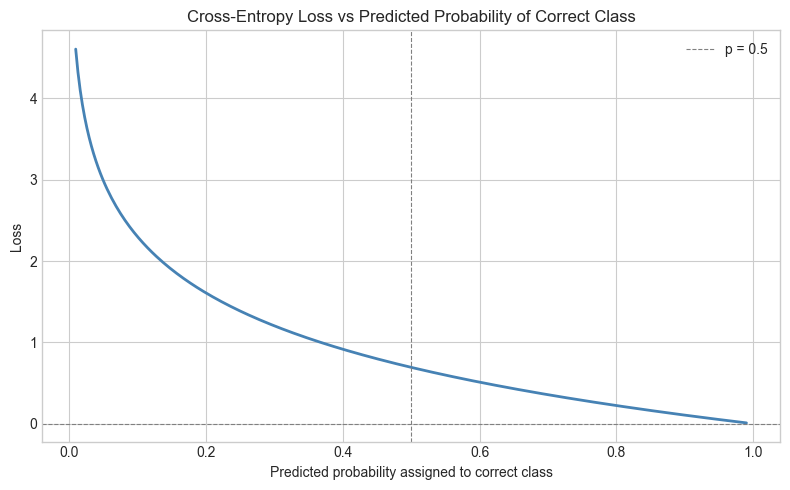

In [11]:
# visualise how loss changes as predicted probability of correct class varies
p_correct = np.linspace(0.01, 0.99, 300)
cross_entropy_loss = -np.log(p_correct)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(p_correct, cross_entropy_loss, color="steelblue", linewidth=2)
ax.set_title("Cross-Entropy Loss vs Predicted Probability of Correct Class")
ax.set_xlabel("Predicted probability assigned to correct class")
ax.set_ylabel("Loss")
ax.axvline(0.5, color="grey", linestyle="--", linewidth=0.8, label="p = 0.5")
ax.axhline(0.0, color="grey", linestyle="--", linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()

### Observation

The three manual examples make the loss behaviour concrete:
- When the model is confident and correct, loss is very low (near 0)
- When the model is uncertain, loss is moderate (around 1.0)
- When the model is confident and wrong, loss is very high

The plot shows why this works as a training signal. The curve is steep near p = 0,
meaning the gradient pushes weights hard when the model is confidently wrong. Near
p = 1, the curve flattens, meaning small adjustments are made when the model is
already doing well.

One thing I want to remember: `CrossEntropyLoss` in PyTorch expects raw logits, not
probabilities. Passing softmax output into it would apply softmax twice and silently
produce wrong gradients — a bug that would be hard to catch from the loss curve alone.

## Training Loop

The training loop is where learning actually happens. Each pass through the full
training dataset is called an epoch. Within each epoch, the loop iterates over
mini-batches from the DataLoader and performs four steps for each batch:

1. **Forward pass** — feed the input through the network and get predictions
2. **Compute loss** — measure how wrong the predictions are using CrossEntropyLoss
3. **Backward pass** — compute gradients of the loss with respect to every parameter
4. **Optimiser step** — update the weights in the direction that reduces the loss

One step that is easy to forget: `optimizer.zero_grad()` must be called before each
backward pass. PyTorch accumulates gradients by default — if you do not zero them out,
gradients from the previous batch add to the current batch's gradients and the updates
become wrong.

I am using the Adam optimiser. Adam adapts the learning rate for each parameter
individually based on past gradients, which makes it more robust than plain SGD and
a good default choice for most problems.

After each epoch I also run a validation pass over the test set with
`torch.no_grad()` — this disables gradient computation since we are only measuring
performance, not updating weights. This keeps evaluation fast and memory efficient.

In [12]:
LEARNING_RATE = 0.001
NUM_EPOCHS    = 100

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

train_losses = []
test_losses  = []
train_accuracies = []
test_accuracies  = []

for epoch in range(1, NUM_EPOCHS + 1):

    # --- training phase ---
    model.train()
    batch_losses = []
    correct = 0
    total   = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()

        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)

        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())
        predicted_classes = predictions.argmax(dim=1)
        correct += (predicted_classes == y_batch).sum().item()
        total   += y_batch.size(0)

    epoch_train_loss = np.mean(batch_losses)
    epoch_train_acc  = correct / total
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    # --- evaluation phase ---
    model.eval()
    batch_losses = []
    correct = 0
    total   = 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)

            batch_losses.append(loss.item())
            predicted_classes = predictions.argmax(dim=1)
            correct += (predicted_classes == y_batch).sum().item()
            total   += y_batch.size(0)

    epoch_test_loss = np.mean(batch_losses)
    epoch_test_acc  = correct / total
    test_losses.append(epoch_test_loss)
    test_accuracies.append(epoch_test_acc)

    if epoch % 10 == 0:
        print(
            f"Epoch {epoch:3d}/{NUM_EPOCHS} | "
            f"Train Loss: {epoch_train_loss:.4f} | "
            f"Train Acc: {epoch_train_acc:.4f} | "
            f"Test Loss: {epoch_test_loss:.4f} | "
            f"Test Acc: {epoch_test_acc:.4f}"
        )

Epoch  10/100 | Train Loss: 0.8790 | Train Acc: 0.7417 | Test Loss: 0.8665 | Test Acc: 0.7000
Epoch  20/100 | Train Loss: 0.5071 | Train Acc: 0.8333 | Test Loss: 0.5240 | Test Acc: 0.8000
Epoch  30/100 | Train Loss: 0.3048 | Train Acc: 0.9083 | Test Loss: 0.3526 | Test Acc: 0.8000
Epoch  40/100 | Train Loss: 0.2119 | Train Acc: 0.9333 | Test Loss: 0.2666 | Test Acc: 0.9000
Epoch  50/100 | Train Loss: 0.1605 | Train Acc: 0.9583 | Test Loss: 0.2144 | Test Acc: 0.9333
Epoch  60/100 | Train Loss: 0.1230 | Train Acc: 0.9583 | Test Loss: 0.1775 | Test Acc: 0.9333
Epoch  70/100 | Train Loss: 0.0982 | Train Acc: 0.9583 | Test Loss: 0.1503 | Test Acc: 0.9333
Epoch  80/100 | Train Loss: 0.0800 | Train Acc: 0.9583 | Test Loss: 0.1319 | Test Acc: 0.9333
Epoch  90/100 | Train Loss: 0.0684 | Train Acc: 0.9750 | Test Loss: 0.1196 | Test Acc: 0.9333
Epoch 100/100 | Train Loss: 0.0682 | Train Acc: 0.9750 | Test Loss: 0.1096 | Test Acc: 0.9333


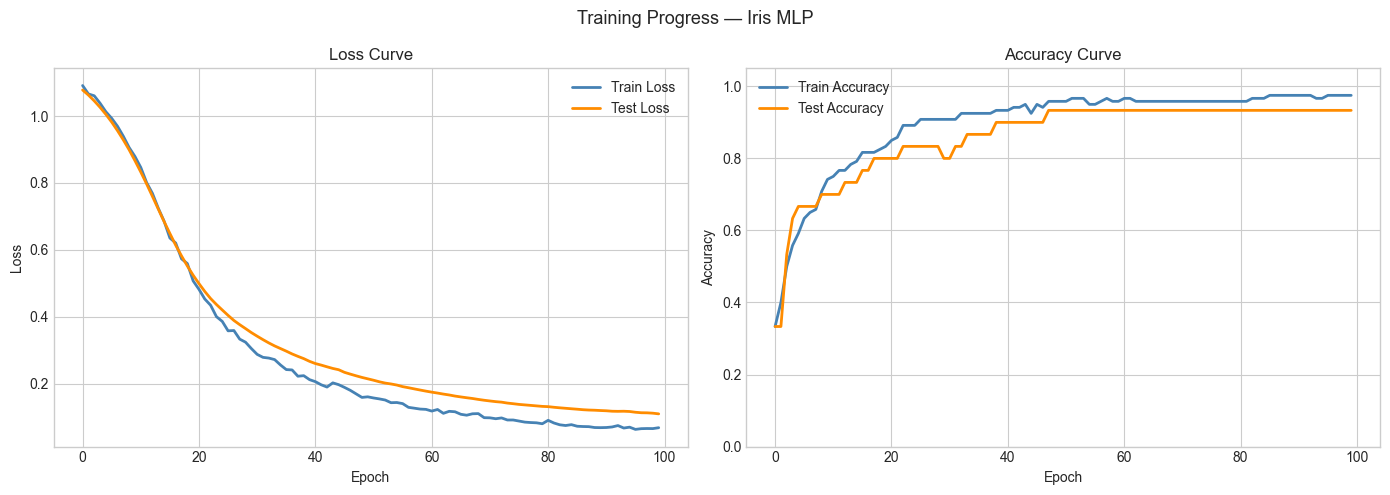

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# loss curve
axes[0].plot(train_losses, color="steelblue",  linewidth=2, label="Train Loss")
axes[0].plot(test_losses,  color="darkorange", linewidth=2, label="Test Loss")
axes[0].set_title("Loss Curve")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

# accuracy curve
axes[1].plot(train_accuracies, color="steelblue",  linewidth=2, label="Train Accuracy")
axes[1].plot(test_accuracies,  color="darkorange", linewidth=2, label="Test Accuracy")
axes[1].set_title("Accuracy Curve")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1.05)
axes[1].legend()

plt.suptitle("Training Progress — Iris MLP", fontsize=13)
plt.tight_layout()
plt.show()

### Observation

The loss curves show whether training is progressing correctly. What I am looking for:
- Both train and test loss should decrease steadily over epochs
- If train loss drops but test loss stays high or rises, the model is overfitting
- If both losses remain high, the model is underfitting — likely needs more capacity
  or more epochs

For Iris, given the simplicity of the dataset, I expect both curves to converge
closely. The accuracy curves should reach above 95% on both sets within 100 epochs.

The gap between train and test curves is worth watching. A small gap is normal —
the model has seen training data and not test data. A large and growing gap would
signal that the model is memorising rather than generalising.

## Evaluation

The loss and accuracy curves give a high-level view of training progress, but they do
not tell me where the model is making mistakes. For that I need to look at predictions
at the class level.

A confusion matrix shows exactly this — for each true class, it shows how many samples
were predicted correctly and how many were confused with other classes. The rows
represent true labels and the columns represent predicted labels. A perfect classifier
produces a diagonal matrix with zeros everywhere else.

For Iris specifically I am curious whether the model confuses Versicolor and Virginica
— these two classes are known to overlap in feature space, unlike Setosa which is
linearly separable from the other two.

In [14]:
model.eval()

all_predictions = []
all_true_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        predictions = model(X_batch)
        predicted_classes = predictions.argmax(dim=1)
        all_predictions.extend(predicted_classes.numpy())
        all_true_labels.extend(y_batch.numpy())

all_predictions = np.array(all_predictions)
all_true_labels = np.array(all_true_labels)

final_accuracy = (all_predictions == all_true_labels).mean()
print(f"Final Test Accuracy: {final_accuracy:.4f} ({final_accuracy*100:.1f}%)")
print()

# per class accuracy
for i, name in enumerate(class_names):
    mask = all_true_labels == i
    class_acc = (all_predictions[mask] == all_true_labels[mask]).mean()
    print(f"  {name:15s} accuracy: {class_acc:.4f}")

Final Test Accuracy: 0.9333 (93.3%)

  setosa          accuracy: 1.0000
  versicolor      accuracy: 0.9000
  virginica       accuracy: 0.9000


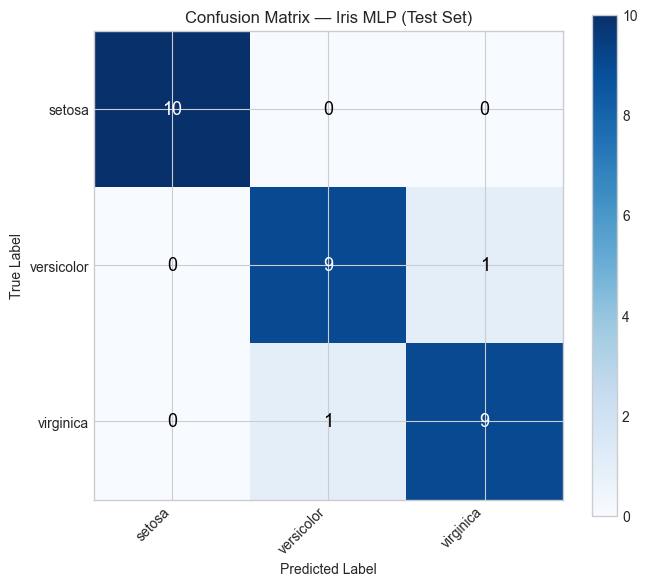

In [15]:
cm = confusion_matrix(all_true_labels, all_predictions)

fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
plt.colorbar(im, ax=ax)

ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

ax.set_title("Confusion Matrix — Iris MLP (Test Set)")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                fontsize=13, color=color)

plt.tight_layout()
plt.show()

### Observation

The confusion matrix gives a much richer picture than a single accuracy number. Each
cell shows the count of samples with that true/predicted class combination.

The diagonal cells are correct predictions. Off-diagonal cells are misclassifications.
For Iris I expect:
- Setosa (row 0) to be perfectly classified — it is linearly separable
- Any errors to appear between Versicolor and Virginica — their feature distributions
  overlap in the original dataset

Per-class accuracy breakdown is also useful here. If overall accuracy is 97% but one
class has 80% accuracy, that is something worth investigating before declaring the
model done.

This is the point where I would ask: are the misclassified samples genuinely ambiguous
in feature space, or is there a data quality issue? For a learning exercise Iris is
clean, but in a real project this question matters significantly.

## Key Takeaways

This section is my learning journal for this notebook — what landed, what surprised me,
and what I want to explore further.

### What I Built

A 3-layer MLP in PyTorch trained on the Iris dataset to classify flowers into three
species. The network has 243 trainable parameters and was trained for 100 epochs using
Adam and CrossEntropyLoss.

### What I Now Understand Better

**Perceptron mechanics**
A single neuron is just a weighted sum plus a bias, passed through an activation
function. There is no magic — it is a linear transformation followed by a non-linearity.
The non-linearity is what gives neural networks their expressive power.

**Why activation functions are not optional**
Without activations, any number of stacked linear layers collapses into a single linear
transformation. ReLU breaks this by introducing a non-linearity that is cheap to compute
and does not suffer from vanishing gradients in the positive region.

**CrossEntropyLoss expects logits, not probabilities**
This is a PyTorch-specific detail that is easy to get wrong. The loss function applies
LogSoftmax internally. Passing softmax output into it applies the operation twice and
produces silently wrong gradients — the training loop would still run without errors.

**The four steps of a training loop**
zero_grad → forward pass → loss.backward() → optimizer.step(). The order matters and
zero_grad is the one most likely to be forgotten when writing from scratch.

**What the confusion matrix adds**
Overall accuracy is a single number that can hide per-class weaknesses. The confusion
matrix shows exactly where the model is making mistakes and which classes it is
confusing with each other.

### What Surprised Me

The model converges quickly on Iris — loss drops sharply in the first 20 epochs and
then flattens. I expected more instability with random weight initialisation but the
Adam optimiser handles this well out of the box.

The parameter count (243) feels large for 120 training samples, yet the model
generalises well. This made me think more carefully about what overfitting actually
requires — capacity alone is not enough, the optimiser and data distribution matter too.

### Open Questions

- What does the loss landscape actually look like for this network? Is there one clear
  minimum or many?
- How much does weight initialisation affect final accuracy on a problem this simple?
- At what point does adding more hidden layers or neurons stop helping and start
  hurting on a dataset this size?
- How would the training curve change if I removed normalisation entirely?



In [16]:
# paste this in a new code cell as a sanity check
print("Notebook 1 complete")
print(f"Final test accuracy : {final_accuracy*100:.1f}%")
print(f"Total parameters    : {sum(p.numel() for p in model.parameters() if p.requires_grad)}")
print(f"Epochs trained      : {NUM_EPOCHS}")

Notebook 1 complete
Final test accuracy : 93.3%
Total parameters    : 243
Epochs trained      : 100
